**Building an Image Classifier with CNN using MNIST Dataset**

In [1]:
# import required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


Preprocess the Data

In [2]:
# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("New shape:", x_train.shape)

New shape: (60000, 28, 28, 1)


**Build the CNN Model**


In [3]:
model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [4]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [5]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.8996 - loss: 0.3272 - val_accuracy: 0.9817 - val_loss: 0.0629
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9674 - loss: 0.1092 - val_accuracy: 0.9858 - val_loss: 0.0516
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - accuracy: 0.9764 - loss: 0.0773 - val_accuracy: 0.9892 - val_loss: 0.0390
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - accuracy: 0.9794 - loss: 0.0681 - val_accuracy: 0.9902 - val_loss: 0.0343
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.9823 - loss: 0.0565 - val_accuracy: 0.9888 - val_loss: 0.0368
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9841 - loss: 0.0514 - val_accuracy: 0.9918 - val_loss: 0.0305
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9859 - loss: 0.0445 - val_accuracy: 0.9915 - val_loss: 0.0301
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9874 - loss: 0.0404 - 

Evaluate the Model

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9927 - loss: 0.0205
Test Accuracy: 0.9926999807357788


Save the Model

In [8]:
model.save("mnist_cnn_model.h5")

Test Model with Custom images

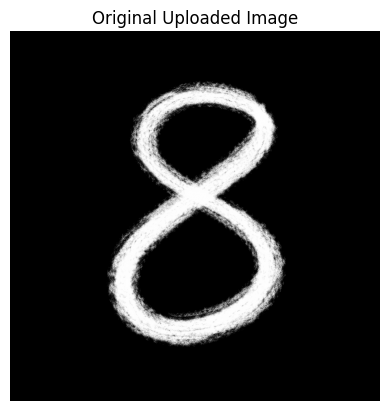

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Digit: 8


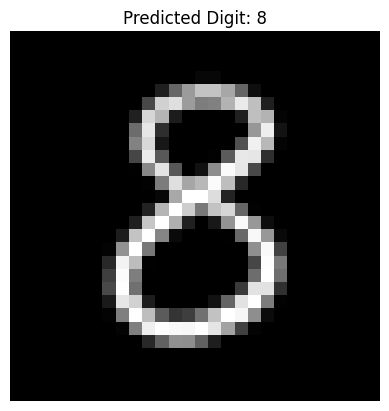

In [15]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open("digit.png").convert("L")

# Show original image
plt.imshow(img, cmap='gray')
plt.title("Original Uploaded Image")
plt.axis('off')
plt.show()

# Resize image for model
img = img.resize((28,28))

img_array = np.array(img)

# Normalize
img_array = img_array / 255.0

# Reshape for CNN
img_array = img_array.reshape(1,28,28,1)

# Predict
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

# Visualize processed image with prediction
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis('off')
plt.show()

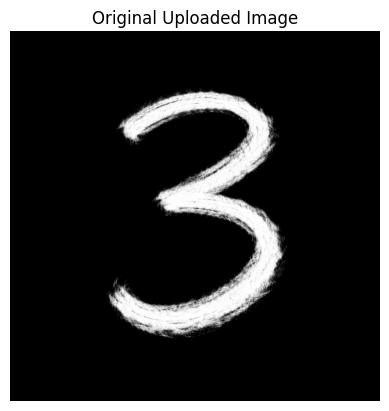

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Digit: 3


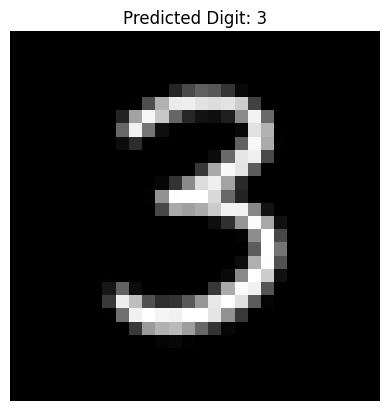

In [14]:

# Load image
img = Image.open("digit1.png").convert("L")

# Show original image
plt.imshow(img, cmap='gray')
plt.title("Original Uploaded Image")
plt.axis('off')
plt.show()

# Resize image for model
img = img.resize((28,28))

img_array = np.array(img)

# Normalize
img_array = img_array / 255.0

# Reshape for CNN
img_array = img_array.reshape(1,28,28,1)

# Predict
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

# Visualize processed image with prediction
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis('off')
plt.show()

Example Visualisation

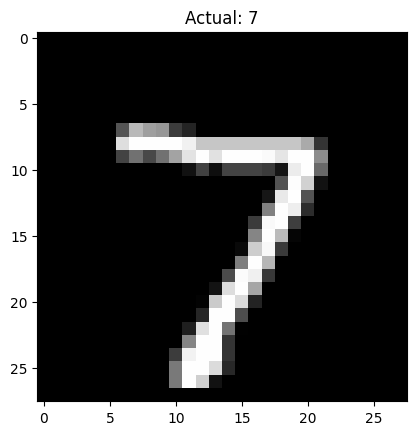

In [7]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Actual: {}".format(np.argmax(y_test[0])))
plt.show()

In [9]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Test Accuracy:", test_acc)

Training Accuracy: 0.989814817905426
Validation Accuracy: 0.9919999837875366
Test Accuracy: 0.9926999807357788


**Conclusion**

In this assignment, a Convolutional Neural Network was successfully implemented to classify handwritten digits using the MNIST dataset. Proper data preprocessing, CNN architecture design, and model training enabled the model to achieve high accuracy.

The trained model demonstrated strong performance on both the test dataset and custom handwritten images. This assignment highlights the effectiveness of CNNs for image classification tasks.